# Lab 6-Basic Data Manipulation and Visualization



# **Assignment Submission Guidelines**

Please follow the guidelines below for submitting your assignment:

1. **Submission Deadline:**
   - All assignments must be submitted **no later than 11:59 PM Next Wednesday (07/15) Midnight**.
   - Late submissions will not be accepted unless prior arrangements have been made by the instructor.

2. **Required Files:**
   - **Jupyter Notebook file (.ipynb):** Submit the Jupyter Notebook file you used to complete the assignment. The file should contain your well-commented code.
   - **PDF Version (.pdf file):** Additionally, submit a PDF version of your Python code. This can be a printout or export of your script, showing all the code with any necessary explanations or output results included.

3. **File Naming Convention:**
   - Please name your files as follows: `Lastname_Firstname_AssignmentName`
   - Example: `Alex_John_Lab6.ipynb` and `Alex_Johb_Lab6.pdf`

4. **Technical Issues:**
   - If you encounter any technical issues with Canvas or your submission, please contact the TAs immediately **before the deadline** to avoid penalties.


## 1. Load and Inspect Data (10 Points)



Load the 2012_Workplace_Fatalities_by_State.csv file into a Pandas DataFrame.

Display the first 50 rows of data in the first column.

Replace all missing values with 0.

In [1]:
import pandas as pd

df = pd.read_csv('2012_Workplace_Fatalities_by_State.csv')

df = df.dropna(how='all')
df = df[df['State'] != 'Total or National, Average']
df = df.reset_index(drop=True)

display(df[['State']].head(50))

df = df.fillna(0)

,State
0,"South Carolina\n(33.99882060100049, -81.045367..."
1,"West Virginia\n(38.665511497000466, -80.712639..."
2,"Massachusetts\n(42.27687306500047, -72.0826898..."
3,"Tennessee\n(35.680943063000484, -85.7744864219..."
4,"Oklahoma\n(35.472034350000456, -97.52106845499..."
5,"Illinois\n(40.48501278700047, -88.99770813999965)"
6,"Nebraska\n(41.64104043900045, -99.36571864599966)"
7,"Delaware\n(39.00883351400046, -75.57773943699965)"
8,"Hawaii\n(21.30485166200043, -157.85774691599974)"
9,"Iowa\n(42.469404401000475, -93.81648936699969)"


##  2. Clean up the state names (10 Points)

The first column that contains both U.S. state names and their coordinates in a messy format. Please remove the coordinates between the state names. Add two columns of longitude and latitude to the data.

In [2]:
df['State'] = df['State'].str.split('\n')

df['Latitude'] = df['State'].str[1].str.strip('()').str.split(',').str[0].astype(float)

df['Longitude'] = df['State'].str[1].str.strip('()').str.split(',').str[1].astype(float)

df['State'] = df['State'].str[0]

df.head()

,State,"Number of Fatalities, 2012","Rate of Fatalities, 2012","State Rank, Fatalities 2012",Number of Injuries/Illnesses 2012,Injuries/Illnesses 2012 Rate,Penalties FY 2013 (Average $),Penalties FY 2013 (Rank),Inspectors,Years to Inspect Each Workplace Once,State or Federal Program,Latitude,Longitude
0,South Carolina,63.0,3.5,25.0,36200.0,3.0,492.0,49.0,24.0,111.0,State,33.998821,-81.045368
1,West Virginia,49.0,6.9,46.0,19800.0,4.1,1798.0,27.0,7.0,173.0,Federal,38.665511,-80.712639
2,Massachusetts,44.0,1.4,1.0,69700.0,3.1,1929.0,21.0,33.0,123.0,Federal,42.276873,-72.082690
3,Tennessee,101.0,3.8,30.0,65100.0,3.5,727.0,45.0,30.0,82.0,State,35.680943,-85.774486
4,Oklahoma,97.0,6.1,42.0,39000.0,3.6,1872.0,24.0,19.0,131.0,Federal,35.472034,-97.521068


## 3. Statistics Summary (a) (10 Points)
Write a Python function named statistics_summary() that summarizes the "State	Number of Fatalities, 2012" distribution. The function include: mean, standard deviation, median,maximum number of fatalities, the index of the maximum number of fatalities, the state name of the maximum number of fatalities, and the histogram plot.

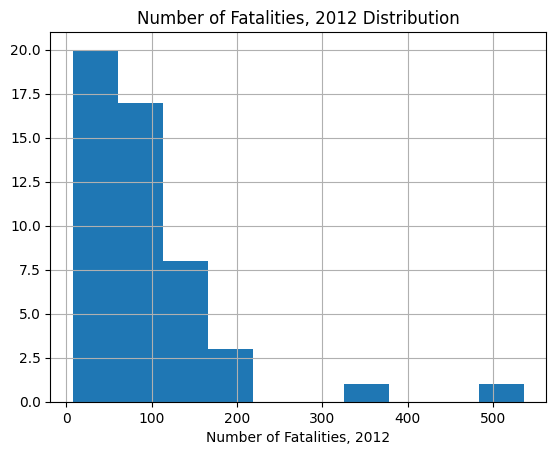

(92.34, 92.01987584766896, 68.5, 536, 48, 'Texas')

In [3]:
import matplotlib.pyplot as plt

def statistics_summary(func_df, column):
    func_df = func_df[func_df['State'] != 'Total or National, Average']  # Removing an unneeded row
    max_state = func_df.sort_values(column, ascending=False).iloc[0, :]
    max_state_name = max_state['State']
    max_state_val = int(max_state[column])
    max_state_index = int(max_state.name)

    func_col = func_df[column]
    func_col.hist()
    plt.title(f'{column} Distribution')
    plt.xlabel(column)
    plt.show()

    return float(func_col.mean()), float(func_col.std()), float(func_col.median()), max_state_val, max_state_index, max_state_name

statistics_summary(df, 'Number of Fatalities, 2012')

## 4. Statistics Summary (b) (10 Points)

By using for loop, show the statistics summary of "Number of Injuries/Illnesses 2012", "Penalties FY 2013", "Inspectors", and "Years to Inspect Each Workplace"

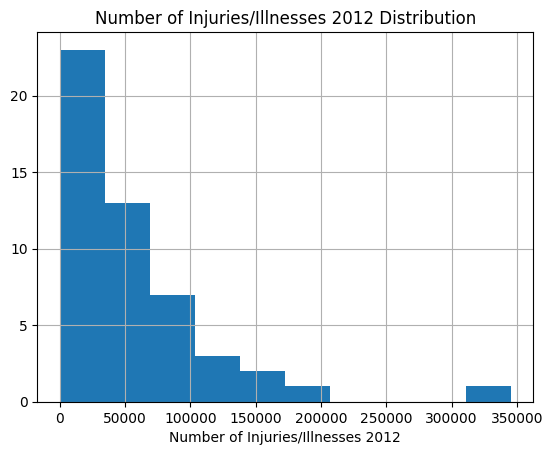

(53910.0, 61418.59802758013, 40100.0, 345400, 49, 'California')


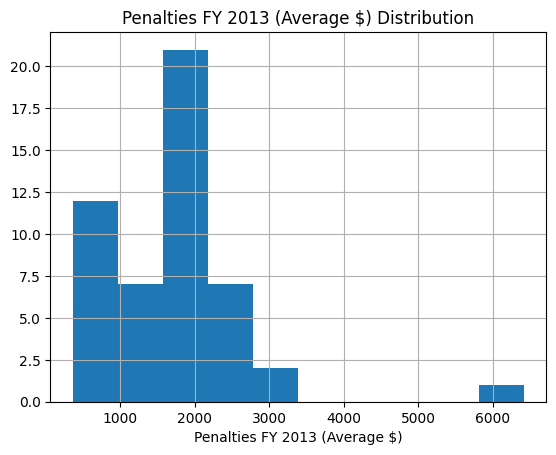

(1727.88, 963.3777024360801, 1812.0, 6422, 49, 'California')


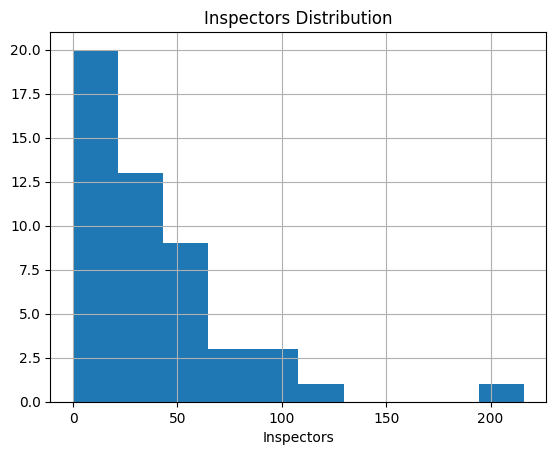

(38.2, 38.5941731882111, 26.0, 216, 49, 'California')


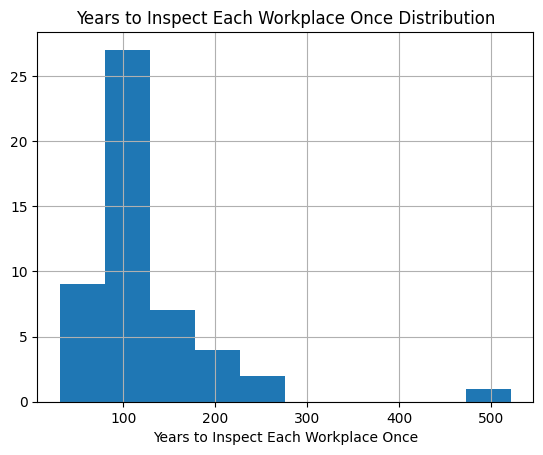

(123.88, 73.31164676243746, 111.5, 521, 20, 'South Dakota')


In [4]:
col_list = ['Number of Injuries/Illnesses 2012', 'Penalties FY 2013 (Average $)', 'Inspectors', 'Years to Inspect Each Workplace Once']

for col in col_list:
	print(statistics_summary(df, col))

## 5. Show the Pair Plot  (30 Points)

Divide the data into two populations based on the "state number of Fatalities, 2012":

one group with Fatalities >= 100, and

the other with Fatalities < 100.

Create the pair plots among all variables, and replace the diagonal plots with 1D histograms.

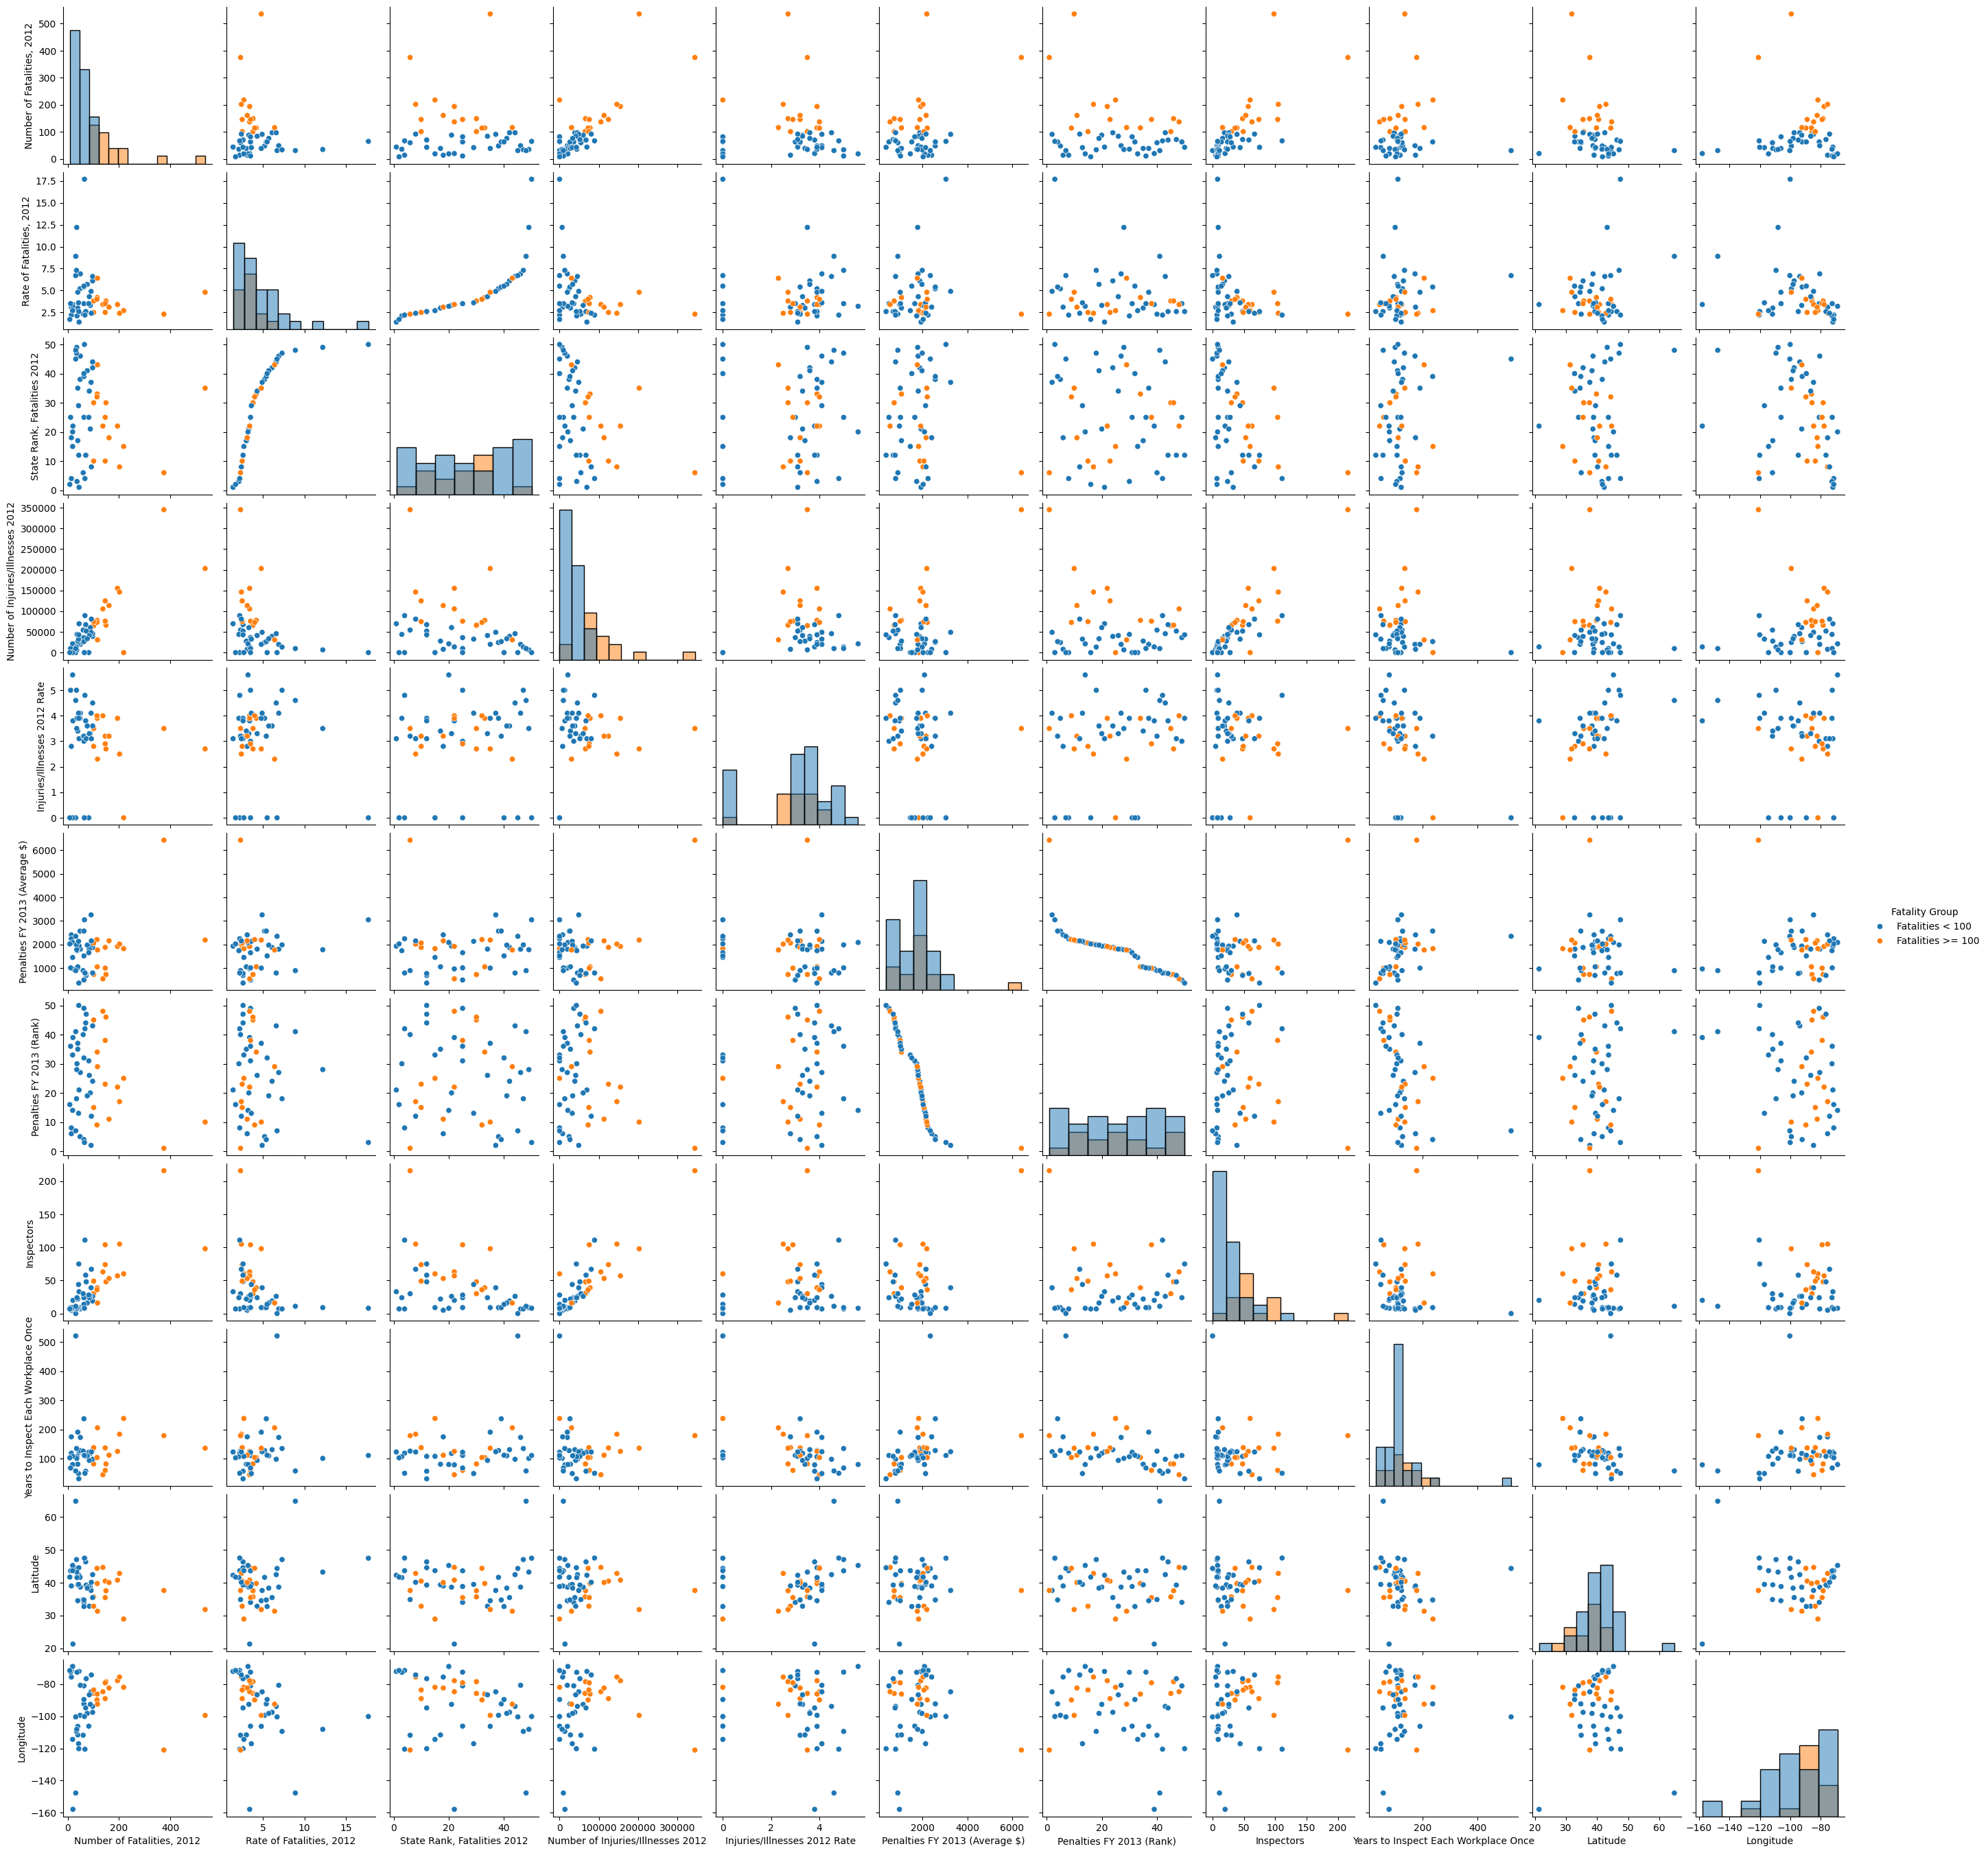

In [5]:
import seaborn as sns

# Label each state based on its number of fatalities
def fatality_group(fatalities):
    if fatalities >= 100:
        return 'Fatalities >= 100'
    else:
        return 'Fatalities < 100'

# Split the states into two groups based on the number of fatalities
df['Fatality Group'] = df['Number of Fatalities, 2012'].apply(fatality_group)

# Pair plot of all variables, colored by group.
# diag_kind='hist' replaces the diagonal plots with 1D histograms.
sns.pairplot(df, hue='Fatality Group', diag_kind='hist')
plt.show()